STEP 1 - google mount drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


STEP 2 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

STEP 4 — Upload Dataset and check files

In [ ]:
import zipfile
import os

with zipfile.ZipFile("mnist_test.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("Test dataset extracted successfully!")
print (os.listdir())

Test dataset extracted successfully!
['.config', 'mnist_test.csv', 'drive', 'mnist_test.csv.zip', 'sample_data']


STEP 5 — Load the Dataset

In [ ]:
train_data = pd.read_csv('/content/sample_data/mnist_train_small.csv')
test_data = pd.read_csv('mnist_test.csv')

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)

Training data shape: (19999, 785)
Testing data shape: (10000, 785)


STEP 6 — Display First 5 Rows

In [ ]:
train_data.head()

,6,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,...,0.581,0.582,0.583,0.584,0.585,0.586,0.587,0.588,0.589,0.590
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


STEP 7 — Check Dataset Information

In [ ]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Columns: 785 entries, 6 to 0.590
dtypes: int64(785)
memory usage: 119.8 MB


STEP 8 — Check Missing Values

In [ ]:
print("Missing values in training data:")
print(train_data.isnull().sum().sum())

print("Missing values in testing data:")
print(test_data.isnull().sum().sum())

Missing values in training data:
0
Missing values in testing data:
0


STEP 9 — Separate Features and Labels

In [4]:
X_train = train_data.drop("6", axis=1)
y_train = train_data["6"]

X_test = test_data.drop("6", axis=1)
y_test = test_data["6"]
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

NameError: name 'train_data' is not defined

STEP 10 — Check the Labels

In [ ]:
print("Classes:", sorted(y_train.unique()))

Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


STEP 11 — Display a Handwritten Digit

In [2]:
plt.figure(figsize=(4,4))

plt.imshow(X_train.iloc[0].values.reshape(28, 28), cmap="gray")
plt.title("Digit: " + str(y_train.iloc[0]))
plt.axis("off")

plt.show()

NameError: name 'plt' is not defined

STEP 12 — Display Multiple Images

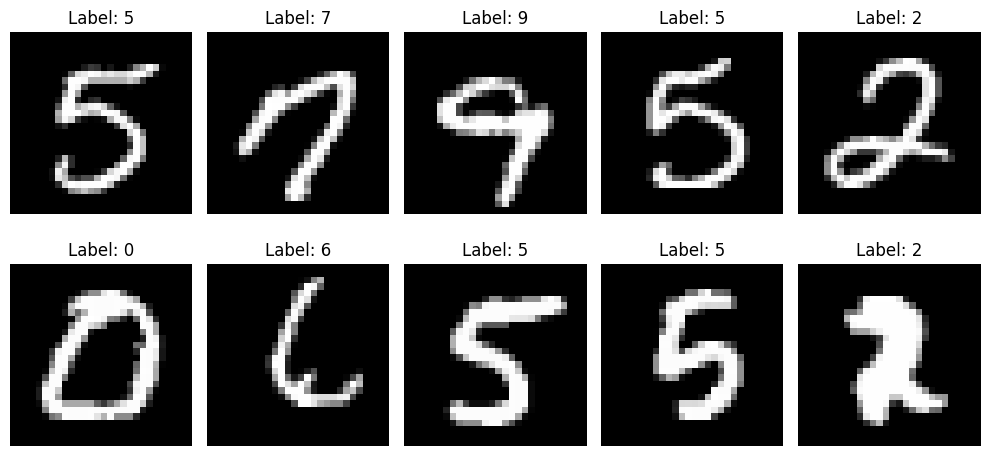

In [ ]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train.iloc[i].values.reshape(28,28), cmap="gray")
    plt.title("Label: " + str(y_train.iloc[i]))
    plt.axis("off")

plt.tight_layout()
plt.show()

STEP 13 — Normalize Pixel Values

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (19999, 784)
X_test shape: (10000, 784)


STEP 14 — Reshape Images

In [ ]:
X_train = X_train.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (19999, 28, 28, 1)
Testing shape: (10000, 28, 28, 1)


STEP 15 — Build the CNN Model

In [ ]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation="relu", input_shape=(28,28,1)))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation="relu"))
model.add(MaxPooling2D((2,2)))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(10, activation="softmax"))

STEP 16 — Display Model Summary

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

STEP 17 — Compile the Model

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

STEP 18 — Train the Model

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.3075 - loss: 1.9443 - val_accuracy: 0.7680 - val_loss: 0.8157
Epoch 2/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 63ms/step - accuracy: 0.7367 - loss: 0.7939 - val_accuracy: 0.8425 - val_loss: 0.5171
Epoch 3/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 17s 60ms/step - accuracy: 0.8032 - loss: 0.6160 - val_accuracy: 0.8810 - val_loss: 0.3941
Epoch 4/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 22s 65ms/step - accuracy: 0.8299 - loss: 0.5274 - val_accuracy: 0.9000 - val_loss: 0.3416
Epoch 5/5
282/282 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.8512 - loss: 0.4781 - val_accuracy: 0.9060 - val_loss: 0.3019


STEP 19 — Plot Training Accuracy

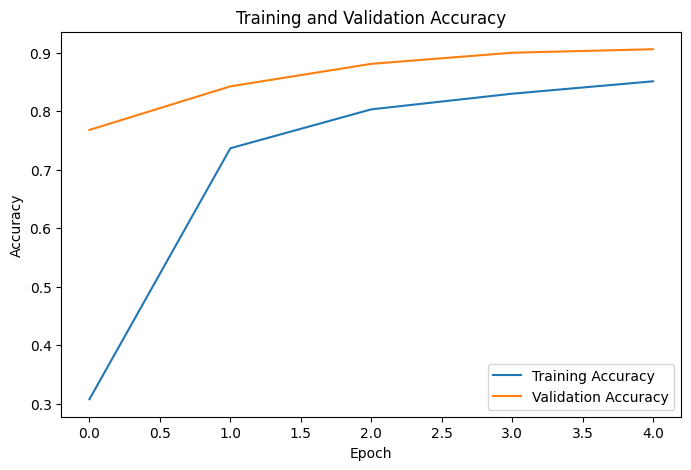

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()

plt.show()

STEP 20 — Plot Training Loss

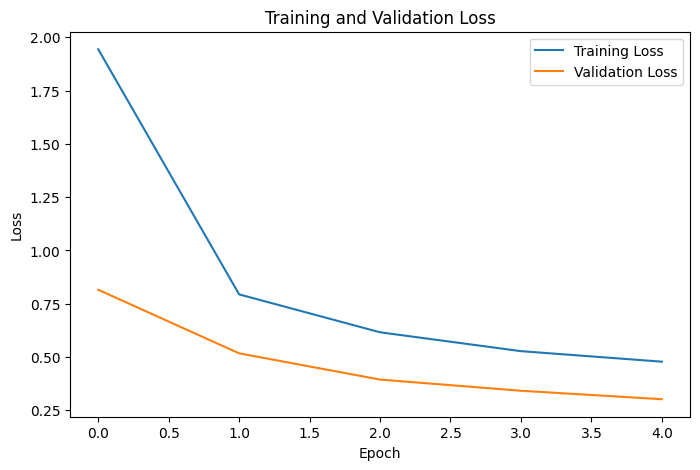

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

STEP 21 — Evaluate the Model

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.9193 - loss: 0.2721
Test Loss: 0.2720506191253662
Test Accuracy: 0.9193000197410583


STEP 22 — Confusion Matrix

In [ ]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step


then create the confusion matrix

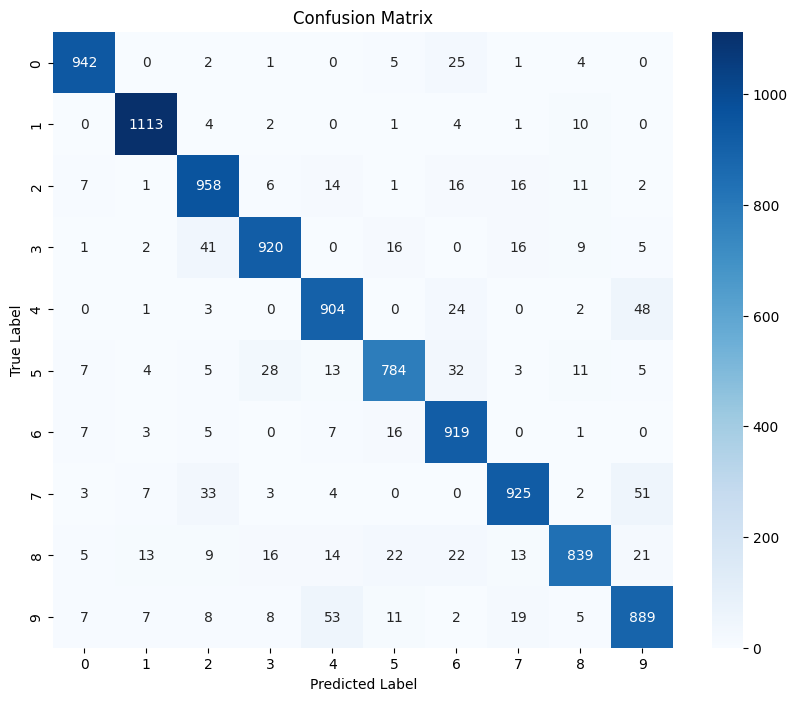

In [ ]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

STEP 23 — Classification Report

In [ ]:
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       980
           1       0.97      0.98      0.97      1135
           2       0.90      0.93      0.91      1032
           3       0.93      0.91      0.92      1010
           4       0.90      0.92      0.91       982
           5       0.92      0.88      0.90       892
           6       0.88      0.96      0.92       958
           7       0.93      0.90      0.91      1028
           8       0.94      0.86      0.90       974
           9       0.87      0.88      0.88      1009

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



STEP 24 — Test Individual Handwritten Digits

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


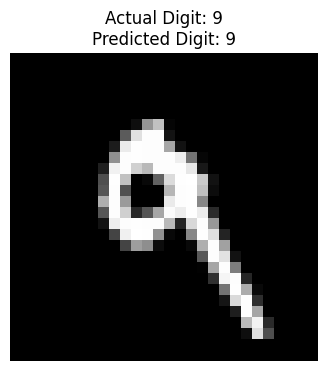

In [ ]:
index = 7

image = X_test[index]

prediction = model.predict(image.reshape(1,28,28,1))
predicted_digit = np.argmax(prediction)

plt.figure(figsize=(4,4))

plt.imshow(image.reshape(28,28), cmap="grey")
plt.title(
    "Actual Digit: " + str(y_test.iloc[index]) +
    "\nPredicted Digit: " + str(predicted_digit)
)
plt.axis("off")

plt.show()